# 🧠 Lab 1: 트랜스포머 & 대형 언어 모델 — 자기 주의 메커니즘부터 텍스트 생성까지 (30분)

**목표**: GPT의 핵심 알고리즘 Transformer의 핵심 메커니즘(자기 주의, Self-Attention)을 이해하고, 작디 작은 GPT를 처음부터 직접 구현한 뒤, 실제 텍스트로 학습하여 학습 전과 후의 텍스트 생성 결과를 비교해보자.

---

## Timeline

| Year | Model | Key Idea |
|------|-------|----------|
| 2017 | **Transformer** | Self-Attention replaces RNN/CNN |
| 2018 | **GPT-1** | Transformer Decoder for text generation |
| 2020 | **GPT-3** | Scale up to 175B parameters |
| 2023+ | **LLM Era** | GPT-4, LLaMA, Qwen, EXAONE... |

## Part 1: Self-Attention 구현

모든 트랜스포머의 **핵심** 은 self-attention이다.

문장 *"The cat sat on the mat"* 에서, Self-Attention은 *"cat"* (누가)이 *"mat"* (어디에?)에 앉았는지 집중할 수 있다.

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import time

torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Device: {device}")
print(f"   현재 사용가능한 GPU 이름: {torch.cuda.get_device_name(0)}")

✅ Device: cuda
   현재 사용가능한 GPU 이름: NVIDIA GeForce RTX 4090


In [13]:
# ============================================================
# Step 1: Implement Scaled Dot-Product Attention from scratch
# ============================================================

def self_attention(query, key, value):
    """
    Scaled Dot-Product Attention
    Formula: Attention(Q, K, V) = softmax(Q @ K^T / sqrt(d_k)) @ V
    """
    d_k = query.size(-1)
    
    # 1. Dot product of Q and K → similarity scores
    scores = torch.matmul(query, key.transpose(-2, -1))
    print(f"1) Q @ K^T (유사도 점수):\n{scores}")
    
    # 2. Scale by sqrt(d_k) → prevent large values
    scores = scores / (d_k ** 0.5)
    print(f"\n2) 스케일링 후 (÷ sqrt({d_k}) = {d_k**0.5:.1f}):\n{scores}")
    
    # 3. Softmax → convert to probabilities (each row sums to 1)
    attention_weights = F.softmax(scores, dim=-1)
    print(f"\n3) softmax 적용 후 (attention weights):\n{attention_weights}")
    print(f"   Row sums: {attention_weights.sum(dim=-1)}")
    
    # 4. Weighted sum of V → final output
    output = torch.matmul(attention_weights, value)
    return output, attention_weights


# Example: 4 tokens, each 8-dim embedding
tokens = ["The", "cat", "sat", "quietly"]
seq_len, d_model = len(tokens), 8

x = torch.randn(seq_len, d_model)
print(f"입력 텐서: {seq_len} 토큰 × {d_model} 차원")
for i, tok in enumerate(tokens):
    print(f"  '{tok}': {x[i][:4].tolist()} ...")

# Q, K, V projections (learnable in real models)
W_q = nn.Linear(d_model, d_model, bias=False)
W_k = nn.Linear(d_model, d_model, bias=False)
W_v = nn.Linear(d_model, d_model, bias=False)

Q, K, V = W_q(x), W_k(x), W_v(x)
print(f"\nQ, K, V 모양: {Q.shape}")
print("=" * 50)

output, weights = self_attention(Q, K, V)
print(f"\n4) 출력 모양: {output.shape}")
print(f"   입력값과 크기는 같지만, 문맥정보가 포함되어 있음")

입력 텐서: 4 토큰 × 8 차원
  'The': [-0.7111086845397949, -0.3866667151451111, 0.9578314423561096, -0.8225308656692505] ...
  'cat': [-0.5223758816719055, -0.7401803731918335, 0.16235657036304474, -0.2369976043701172] ...
  'sat': [1.861944556236267, -1.077892780303955, 0.8848565220832825, -0.8342104554176331] ...
  'quietly': [1.1284750699996948, -1.2123126983642578, 2.602391004562378, -0.09572362899780273] ...

Q, K, V 모양: torch.Size([4, 8])
1) Q @ K^T (유사도 점수):
tensor([[ 0.3775, -1.0826, -0.5548,  0.3908],
        [-0.1881,  0.1868,  0.5924,  0.3027],
        [-2.5066, -0.2721, -1.1512, -1.1199],
        [-3.2320, -0.6029, -0.9972, -1.1658]], grad_fn=<MmBackward0>)

2) 스케일링 후 (÷ sqrt(8) = 2.8):
tensor([[ 0.1335, -0.3828, -0.1962,  0.1382],
        [-0.0665,  0.0660,  0.2094,  0.1070],
        [-0.8862, -0.0962, -0.4070, -0.3960],
        [-1.1427, -0.2132, -0.3526, -0.4122]], grad_fn=<DivBackward0>)

3) softmax 적용 후 (attention weights):
tensor([[0.3011, 0.1797, 0.2166, 0.3026],
        [0.2

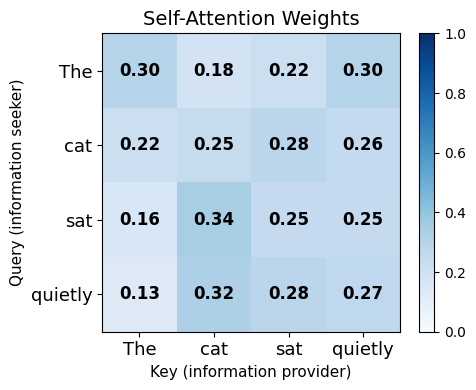

값이 높을수록 이 토큰은 특정 토큰에 더 집중함을 의미함


In [14]:
# ============================================================
# Visualize Attention Weights
# ============================================================

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(weights.detach().numpy(), cmap='Blues', vmin=0, vmax=1)

ax.set_xticks(range(len(tokens)))
ax.set_yticks(range(len(tokens)))
ax.set_xticklabels(tokens, fontsize=13)
ax.set_yticklabels(tokens, fontsize=13)
ax.set_xlabel("Key (information provider)", fontsize=11)
ax.set_ylabel("Query (information seeker)", fontsize=11)
ax.set_title("Self-Attention Weights", fontsize=14)

for i in range(len(tokens)):
    for j in range(len(tokens)):
        ax.text(j, i, f"{weights[i, j]:.2f}",
                ha="center", va="center", fontsize=12, fontweight='bold')

plt.colorbar(im)
plt.tight_layout()
plt.show()

print("값이 높을수록 이 토큰은 특정 토큰에 더 집중함을 의미함")

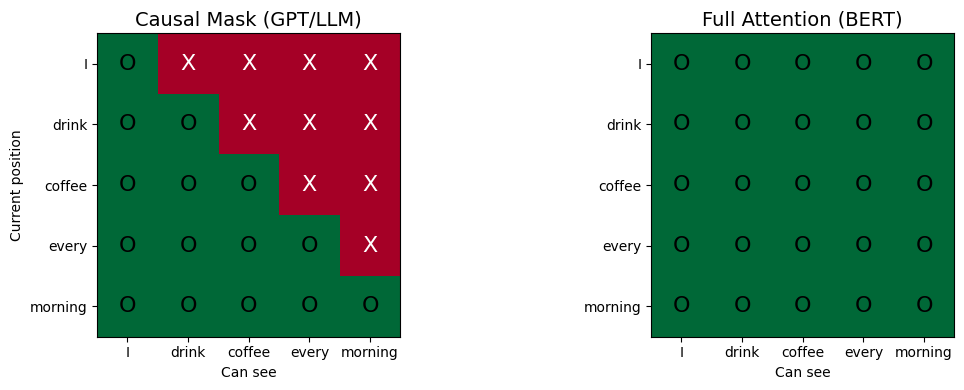

GPT/LLM (왼쪽):  이전 토큰만 볼수 있음 → 생성에 적합
BERT (오른쪽):    모든 토큰을 봄       → 이해하는데 적합


In [16]:
# ============================================================
# Causal Mask — Why LLMs can't see the future
# ============================================================

seq_len = 5
mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels = ["I", "drink", "coffee", "every", "morning"]

# Causal Mask (GPT / LLM)
display = torch.where(mask, torch.tensor(0.0), torch.tensor(1.0))
axes[0].imshow(display, cmap='RdYlGn', vmin=0, vmax=1)
for i in range(seq_len):
    for j in range(seq_len):
        text = "O" if not mask[i, j] else "X"
        color = 'white' if mask[i, j] else 'black'
        axes[0].text(j, i, text, ha='center', va='center', fontsize=16, color=color)
axes[0].set_xticks(range(seq_len)); axes[0].set_yticks(range(seq_len))
axes[0].set_xticklabels(labels, fontsize=10); axes[0].set_yticklabels(labels, fontsize=10)
axes[0].set_title("Causal Mask (GPT/LLM)", fontsize=14)
axes[0].set_xlabel("Can see"); axes[0].set_ylabel("Current position")

# Full Attention (BERT)
axes[1].imshow(torch.ones(seq_len, seq_len), cmap='RdYlGn', vmin=0, vmax=1)
for i in range(seq_len):
    for j in range(seq_len):
        axes[1].text(j, i, "O", ha='center', va='center', fontsize=16)
axes[1].set_xticks(range(seq_len)); axes[1].set_yticks(range(seq_len))
axes[1].set_xticklabels(labels, fontsize=10); axes[1].set_yticklabels(labels, fontsize=10)
axes[1].set_title("Full Attention (BERT)", fontsize=14)
axes[1].set_xlabel("Can see")

plt.tight_layout()
plt.show()

print("GPT/LLM (왼쪽):  이전 토큰만 볼수 있음 → 생성에 적합")
print("BERT (오른쪽):    모든 토큰을 봄       → 이해하는데 적합")

---
## Part 2: 작디작은GPT 만들기 — 진짜 LLM 도전!

이제**진짜** 작디작은 GPT 모델을 설계 및 구현하고 학습을 해볼거에요.

구조:
- **~25M 파라미터**
- 12 Transformer layers, 8 attention heads
- 512 임베딩 차원
- 문자 단위 토큰화

In [44]:
# ============================================================
# Training Data: 한국어 text corpus
# ============================================================

train_text = """
산 너머로 해가 떠올라 골짜기에 황금빛을 뿌렸다. 아침 안개가 서서히 걷히며 새들이 노래하기 시작했다. 부드러운 미풍이 들꽃 향기를 실어 나르고 강물은 따스한 햇살 아래 다이아몬드처럼 반짝였다.
아이들이 오래된 떡갈나무 근처 초원에서 웃으며 뛰어놀았다. 농부는 들판을 돌며 작물을 하나하나 살폈다. 지평선에 먹구름이 모여들어 저녁 비를 예고했다.
오래된 등대는 거센 파도에 맞서 당당히 서 있었다. 파도가 바위에 부딪혀 하얀 포말을 만들었다. 갈매기들이 등대 주위를 맴돌며 울음소리를 냈다.
황혼이 하늘을 보라색으로 물들이자 별들이 하나씩 나타났다. 달빛이 잠든 마을에 은빛 그림자를 드리웠다. 밤바람이 나뭇잎 사이로 속삭이듯 불어왔다.
창가에 앉은 고양이는 조용히 세상을 지켜보았다. 가끔 꼬리를 흔들며 지나가는 나비를 쫓았다. 주인이 돌아오자 고양이는 기지개를 켜며 일어났다.
제빵사는 새벽 네 시에 일어나 반죽을 시작했다. 오븐에서 갓 구운 빵 향기가 거리로 퍼져나갔다. 손님들이 줄을 서서 따끈한 빵을 사 갔다.
학생들은 도서관에 모여 기말고사를 준비했다. 책상 위에 교과서와 노트가 가득 쌓여 있었다. 커피를 마시며 밤늦도록 공부하는 학생도 있었다.
기차가 역을 떠나 북쪽으로 향했다. 창밖으로 시골 풍경이 빠르게 지나갔다. 논과 밭 사이로 작은 마을들이 보였다.
눈이 소리 없이 내려 세상을 하얀 이불로 덮었다. 아이들은 눈사람을 만들고 눈싸움을 했다. 겨울 숲은 고요하고 아름다웠다.
음악가가 무대 위에서 아름다운 선율을 연주했다. 관객들은 숨을 죽이고 음악에 빠져들었다. 마지막 음이 울려 퍼지자 우레와 같은 박수가 터져 나왔다.
가을 낙엽이 바람에 춤추며 땅 위에 무늬를 만들었다. 은행나무 잎이 노란 카펫을 깔아놓은 듯했다. 공원 벤치에 앉아 책을 읽는 사람이 있었다.
과학자는 현미경을 들여다보며 관찰 결과를 꼼꼼히 기록했다. 실험실은 조용했지만 발견의 흥분으로 가득 차 있었다. 오랜 연구 끝에 드디어 새로운 결과가 나왔다.
배 한 척이 별을 따라 바다를 건넜다. 수평선 너머로 해가 지고 하늘이 붉게 물들었다. 선원들은 갑판 위에서 노래를 부르며 항해를 이어갔다.
도시의 불빛이 멀리서 반딧불이처럼 반짝였다. 야경을 바라보며 커피를 마시는 연인이 있었다. 밤이 깊어질수록 도시는 오히려 더 활기를 띠었다.
강아지가 공원을 신나게 뛰어다녔다. 나비를 쫓다가 넘어지기도 하고 꽃밭에 코를 박기도 했다. 주인은 웃으며 강아지를 지켜보았다.
비가 지붕 위를 두드리며 잔잔한 리듬을 만들었다. 빗소리를 들으며 차를 마시는 오후는 평화로웠다. 창밖의 빗줄기가 유리창에 줄무늬를 그렸다.
화가는 대담한 색채로 석양을 캔버스에 담았다. 붓 터치 하나하나에 감정이 실려 있었다. 완성된 그림은 보는 이의 마음을 사로잡았다.
폭풍이 몰고 온 바람이 빈 거리를 휩쓸었다. 간판이 흔들리고 나뭇가지가 꺾여 날아갔다. 사람들은 서둘러 건물 안으로 피했다.
선생님은 칠판에 수식을 적으며 설명했다. 학생들의 눈이 반짝이며 고개를 끄덕였다. 드디어 어려운 개념을 이해한 순간이었다.
할머니는 마당에서 고추를 말리고 있었다. 햇볕이 좋은 날이면 항상 마당에 나와 일을 했다. 손자가 놀러 오면 맛있는 떡을 만들어 주셨다.
시장 골목에는 온갖 먹거리가 넘쳐났다. 떡볶이 냄새와 어묵 국물 향기가 뒤섞였다. 사람들의 웃음소리와 흥정하는 소리로 시끌벅적했다.
봄이 오자 벚꽃이 만개하여 거리가 분홍빛으로 물들었다. 꽃잎이 바람에 날려 눈처럼 흩날렸다. 연인들은 벚꽃 아래에서 사진을 찍었다.
여름밤 하늘에 별똥별이 쏟아졌다. 잔디밭에 누워 밤하늘을 올려다보았다. 은하수가 하늘을 가로지르며 장관을 이루었다.
할아버지는 나무 의자에 앉아 낚시를 하고 계셨다. 호수는 거울처럼 고요하고 잠자리가 수면 위를 날았다. 물고기가 한 마리 잡히자 할아버지는 환하게 웃으셨다.
작은 카페에서 재즈 음악이 흘러나왔다. 바리스타가 정성스럽게 라떼 아트를 그렸다. 손님은 창가 자리에 앉아 책을 읽으며 오후를 보냈다.
등산객들이 정상에 올라 환호성을 질렀다. 산 아래로 구름 바다가 펼쳐져 있었다. 시원한 바람이 땀을 식혀주어 기분이 상쾌했다.
어부는 새벽에 배를 끌고 바다로 나갔다. 그물을 던지고 물고기가 잡히기를 기다렸다. 해가 뜰 무렵 배 가득 물고기를 싣고 돌아왔다.
축제 마당에 풍물 소리가 울려 퍼졌다. 사물놀이 장단에 맞춰 사람들이 어깨를 들썩였다. 아이들은 솜사탕을 들고 이리저리 뛰어다녔다.
비 갠 후 무지개가 하늘에 걸렸다. 일곱 가지 색이 선명하게 보였다. 사람들은 발길을 멈추고 하늘을 올려다보았다.
겨울 아침 창문에 성에가 꽃처럼 피어 있었다. 따뜻한 코코아 한 잔이 손을 녹여주었다. 벽난로 앞에서 담요를 덮고 책을 읽는 것이 최고의 행복이었다.
""".strip()

# Character-level tokenizer
chars = sorted(list(set(train_text)))
vocab_size = len(chars)
char2id = {c: i for i, c in enumerate(chars)}
id2char = {i: c for i, c in enumerate(chars)}

def encode(text):
    return [char2id[c] for c in text]

def decode(ids):
    return ''.join([id2char[i] for i in ids])

data = torch.tensor(encode(train_text), dtype=torch.long)

print(f"Corpus length: {len(train_text)} characters")
print(f"Vocabulary size: {vocab_size} unique characters")
print(f"Characters: {''.join(chars)}")
print(f"\nEncoding example:")
print(f"  '산 너머' → {encode('산 너머')}")
print(f"  {encode('산 너머')} → '{decode(encode('산 너머'))}'")

Corpus length: 2320 characters
Vocabulary size: 380 unique characters
Characters: 
 .가간갈감갑갓갔강갖같개객갠거건걷걸것게겨견결경계고골곱공과관교구국그근금기길깊깔깨꺾꼬꼼꽃끄끈끌끔끝나낙낚난날났내냄냈너넘넜네녁념녔노녹논놀농놓누눈는늘늦늬니님다단달담당대더덕던덮도돌된두둘뒤드득든들듬듯등디딧딪따땀땅떠떡떼똥뛰뜰뜻띠라란람래랜러럼럽렀레려렵렸로록루르를름리림마막만말맛맞매맴머먹멀멈며면명모목몬몰무묵문물뭇미바박밖반발밤밭배버벅벚벤벽별볕보복볶봄부북분불붉붓붕븐비빈빗빛빠빵뿌사삭산살상새색생서석섞선설성세센셨소속손솜수순숨숲스시식신싣실싸쌓썩쏟쓸씩아악안앉았앞야얀양어없었에여역연엽였예오온올와완왔요용우운울움웃워원웠위유율으은을음의이인일읽있잎자작잔잠잡장재저적정제져졌조좋주죽준줄즈지진질짜짝쪽쫓찍차찰창채책처척쳐초최추축춤춰치칠침카캔커켜코쾌타탕터트파판퍼페펫펼폈평포폭풍피하학한할항해햇했행향험혀현호혼홍화환활황후휩흔흘흥흩히

Encoding example:
  '산 너머' → [202, 1, 62, 149]
  [202, 1, 62, 149] → '산 너머'


In [45]:
# ============================================================
# MiniGPT: A proper GPT architecture (~25M params)
# ============================================================

class MiniGPT(nn.Module):
    def __init__(self, vocab_size, d_model=512, n_heads=8, n_layers=12,
                 max_len=128, dropout=0.1):
        super().__init__()
        self.max_len = max_len
        
        # Embeddings
        self.token_embed = nn.Embedding(vocab_size, d_model)
        self.pos_embed = nn.Embedding(max_len, d_model)
        self.drop = nn.Dropout(dropout)
        
        # Transformer Decoder blocks
        decoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True,  # Pre-LN (modern GPT style)
        )
        self.transformer = nn.TransformerEncoder(decoder_layer, num_layers=n_layers)
        
        # Output head
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)
        
        # Weight tying (same as GPT-2)
        self.head.weight = self.token_embed.weight
        
        self._init_weights()
    
    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)
    
    def forward(self, x):
        B, T = x.shape
        
        tok = self.token_embed(x)
        pos = self.pos_embed(torch.arange(T, device=x.device))
        h = self.drop(tok + pos)
        
        # Causal mask
        mask = nn.Transformer.generate_square_subsequent_mask(T, device=x.device)
        h = self.transformer(h, mask=mask, is_causal=True)
        
        h = self.ln_f(h)
        logits = self.head(h)
        return logits
    
    @torch.no_grad()
    def generate(self, prompt_ids, max_new_tokens=200, temperature=0.8, top_k=40):
        """Autoregressive text generation"""
        self.eval()
        ids = prompt_ids.clone()
        
        for _ in range(max_new_tokens):
            # Crop to max_len
            context = ids[:, -self.max_len:]
            logits = self(context)
            logits = logits[:, -1, :] / temperature
            
            # Top-k sampling
            if top_k > 0:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = float('-inf')
            
            probs = F.softmax(logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1)
            ids = torch.cat([ids, next_id], dim=1)
        
        return ids


# Create model
model = MiniGPT(
    vocab_size=vocab_size,
    d_model=512,
    n_heads=8,
    n_layers=12,
    max_len=128,
).to(device)

param_count = sum(p.numel() for p in model.parameters())
param_mb = sum(p.numel() * p.element_size() for p in model.parameters()) / 1e6

print(f"작디작은GPT 구조:")
print(f"  Layers: 12, Heads: 8, d_model: 512")
print(f"  Parameters: {param_count:,} ({param_mb:.0f} MB)")
print(f"  Context window: 128 tokens")
print(f"\n비교 예시:")
print(f"  GPT-2 Small:  124,000,000 params")
print(f"  LG에서 만든 EXAONE 2.4B: 2,400,000,000 params")
print(f"  LG에서 만든 EXAONE 7.8B: 7,800,000,000 params")

작디작은GPT 구조:
  Layers: 12, Heads: 8, d_model: 512
  Parameters: 38,089,728 (152 MB)
  Context window: 128 tokens

비교 예시:
  GPT-2 Small:  124,000,000 params
  LG에서 만든 EXAONE 2.4B: 2,400,000,000 params
  LG에서 만든 EXAONE 7.8B: 7,800,000,000 params


c:\Users\user\anaconda3\envs\a\lib\site-packages\torch\nn\modules\transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


---
## Part 3: 학습 전 vs 학습 후 결과 비교

먼저 **학습 전** (랜덤 가중치)모델이 어떤 결과를 생성하는지 보고,
**학습 후** 한국어 corpus에서 모델이 학습해서 어떤 결과를 생성하는지 비교!

In [46]:
# ============================================================
# BEFORE Training: Generate text (random weights)
# ============================================================

prompt = "산 너머"
prompt_ids = torch.tensor([encode(prompt)], dtype=torch.long, device=device)

output_ids = model.generate(prompt_ids, max_new_tokens=150, temperature=1.0)
generated_before = decode(output_ids[0].tolist())

print("=" * 60)
print("학습 전 (랜덤 가중치):")
print("=" * 60)
print(f"입력: '{prompt}'")
print(f"결과: '{generated_before}'")
print("\n→ 이상한 소리 찍찍, 학습의 필요성!")

학습 전 (랜덤 가중치):
입력: '산 너머'
결과: '산 너머줄단라줄뜻줄하근줄폭저쳐라엽근렸빠한렸휩공져라빠한개석딪네렸줄줄져빠줄완뜻완초안완에에줄렸렸네막난라장펫도펫엽줄왔가먹펫피빠피렸벅줄줄빠누자딪완븐븐에듯줄져차피듯쳐져빠피깨져바먹펫피누줄네벅난먹완가부난자바가네울저완장줄줄곱깨왔벅완가왔온환빠먹뜻왔곱완겨자자온뜻갖볕환폭줄피누벅폭막썩벅네네꺾뛰생먹왔'

→ 이상한 소리 찍찍, 학습의 필요성!


In [47]:
# ============================================================
# Training Loop
# ============================================================

# Hyperparameters
BATCH_SIZE = 32
SEQ_LEN = 128
LEARNING_RATE = 3e-4
NUM_STEPS = 500      # Increase for better results (1000+ recommended)
LOG_EVERY = 50

# Dataset: random chunks from training text
def get_batch(batch_size, seq_len):
    """Sample random chunks from the training data"""
    max_start = len(data) - seq_len - 1
    starts = torch.randint(0, max_start, (batch_size,))
    x = torch.stack([data[s:s+seq_len] for s in starts]).to(device)
    y = torch.stack([data[s+1:s+seq_len+1] for s in starts]).to(device)
    return x, y

# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_STEPS)

# Training
model.train()
losses = []
best_loss = float('inf')
best_state = None
start_time = time.time()

print(f"Training MiniGPT for {NUM_STEPS} steps...")
print(f"Batch size: {BATCH_SIZE}, Seq length: {SEQ_LEN}")
print("=" * 60)

for step in range(1, NUM_STEPS + 1):
    x, y = get_batch(BATCH_SIZE, SEQ_LEN)
    
    logits = model(x)
    loss = F.cross_entropy(logits.view(-1, vocab_size), y.view(-1))
    
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    scheduler.step()
    
    losses.append(loss.item())
    
    # Save best model
    if loss.item() < best_loss:
        best_loss = loss.item()
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        best_step = step
    
    if step % LOG_EVERY == 0 or step == 1:
        elapsed = time.time() - start_time
        avg_loss = np.mean(losses[-LOG_EVERY:])
        print(f"  Step {step:4d}/{NUM_STEPS} | Loss: {avg_loss:.4f} | "
              f"Best: {best_loss:.4f} (step {best_step}) | Time: {elapsed:.0f}s")

# Load best model
model.load_state_dict(best_state)
print(f"\n✅ Training complete! Best model loaded from step {best_step} (loss: {best_loss:.4f})")
total_time = time.time() - start_time
print(f"\n✅ Training complete in {total_time:.0f} seconds!")
print(f"   Final loss: {losses[-1]:.4f}")

if device == "cuda":
    vram_used = torch.cuda.max_memory_allocated() / 1e9
    print(f"   Peak VRAM used: {vram_used:.2f} GB")

Training MiniGPT for 500 steps...
Batch size: 32, Seq length: 128
  Step    1/500 | Loss: 6.2883 | Best: 6.2883 (step 1) | Time: 0s
  Step   50/500 | Loss: 4.3492 | Best: 3.4854 (step 50) | Time: 2s
  Step  100/500 | Loss: 2.8883 | Best: 2.2835 (step 100) | Time: 4s
  Step  150/500 | Loss: 1.7252 | Best: 1.1378 (step 149) | Time: 6s
  Step  200/500 | Loss: 0.7345 | Best: 0.4177 (step 199) | Time: 8s
  Step  250/500 | Loss: 0.3005 | Best: 0.2062 (step 249) | Time: 10s
  Step  300/500 | Loss: 0.1749 | Best: 0.1430 (step 291) | Time: 12s
  Step  350/500 | Loss: 0.1313 | Best: 0.1065 (step 344) | Time: 14s
  Step  400/500 | Loss: 0.1111 | Best: 0.0972 (step 389) | Time: 16s
  Step  450/500 | Loss: 0.1020 | Best: 0.0907 (step 435) | Time: 18s
  Step  500/500 | Loss: 0.1016 | Best: 0.0907 (step 435) | Time: 21s

✅ Training complete! Best model loaded from step 435 (loss: 0.0907)

✅ Training complete in 21 seconds!
   Final loss: 0.1102
   Peak VRAM used: 2.73 GB


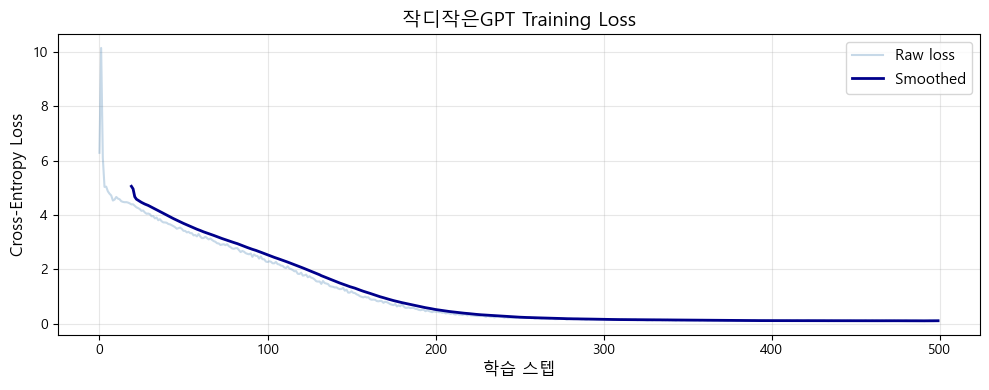

Initial loss: 6.2883 (random guess = -ln(1/380) = 5.9402)
Final loss:   0.1102
→ 그래프를 보면 이 모델이 무작위 예측하는 것보다 훨씬 더 예측을 잘하는 법을 배움


In [48]:
# ============================================================
# Training Loss Curve
# ============================================================

fig, ax = plt.subplots(figsize=(10, 4))

window = 20
smoothed = np.convolve(losses, np.ones(window)/window, mode='valid')

ax.plot(losses, alpha=0.3, color='steelblue', label='Raw loss')
ax.plot(range(window-1, len(losses)), smoothed, color='darkblue', linewidth=2, label='Smoothed')
ax.set_xlabel('학습 스텝', fontsize=12)
ax.set_ylabel('Cross-Entropy Loss', fontsize=12)
ax.set_title('작디작은GPT Training Loss', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Initial loss: {losses[0]:.4f} (random guess = -ln(1/{vocab_size}) = {np.log(vocab_size):.4f})")
print(f"Final loss:   {losses[-1]:.4f}")
print(f"→ 그래프를 보면 이 모델이 무작위 예측하는 것보다 훨씬 더 예측을 잘하는 법을 배움")

In [49]:
# ============================================================
# AFTER Training: Generate text & compare
# ============================================================

prompts = ["산 너머", "아이들이", "별들이 ", "바람 소"]

print("=" * 70)
print("BEFORE vs AFTER Training Comparison")
print("=" * 70)

# Before (we already saved this)
print(f"\n--- BEFORE TRAINING ---")
print(f"Prompt: 'The sun'")
print(f"Output: {generated_before[:100]}...")

print(f"\n--- AFTER TRAINING ---")
model.eval()

for prompt in prompts:
    prompt_ids = torch.tensor([encode(prompt)], dtype=torch.long, device=device)
    output_ids = model.generate(prompt_ids, max_new_tokens=120, temperature=0.7)
    generated = decode(output_ids[0].tolist())
    
    print(f"\nPrompt: '{prompt}'")
    print(f"Output: {generated[:150]}")

print("\n" + "=" * 70)
print("이제 작디작은 GPT는 그럴듯한 한국어 문장을 생성함")
print("훈련의 중요성")
print("=" * 70)

BEFORE vs AFTER Training Comparison

--- BEFORE TRAINING ---
Prompt: 'The sun'
Output: 산 너머줄단라줄뜻줄하근줄폭저쳐라엽근렸빠한렸휩공져라빠한개석딪네렸줄줄져빠줄완뜻완초안완에에줄렸렸네막난라장펫도펫엽줄왔가먹펫피빠피렸벅줄줄빠누자딪완븐븐에듯줄져차피듯쳐져빠피깨져바먹펫피누줄네벅난...

--- AFTER TRAINING ---

Prompt: '산 너머'
Output: 산 너머로 해가 지고 하늘이 붉게 물들었다. 선원들은 갑판 위에서 노래를 부르며 항해를 이어갔다.
도시의 불빛이 멀리서 반딧불이처럼 반짝였다. 야경을 바라보며 커피를 마시는 연인이 있었다. 밤이 깊어질수록 도시는 오히려 활

Prompt: '아이들이'
Output: 아이들이 오래된 떡갈나무 근처 초원에서 웃으며 뛰어놀았다. 농부는 들판을 돌며 작물을 하나하나 살폈다. 지평선에 먹구름이 모여들어 저녁 비를 예고했다.
오래된 등대는 거센 파도에 맞서 당당히 서 있었다. 파도가 바위에 부딪

Prompt: '별들이 '
Output: 별들이 하나씩 나타났다. 달빛이 잠든 마을에 은빛 그림자를 드리웠다. 밤바람이 나뭇잎 사이로 속삭이듯 불어왔다.
창가에 앉은 고양이는 조용히 세상을 지켜보았다. 가끔 꼬리를 흔들며 지나가는 나비를 쫓았다. 주인이 돌아오자 

Prompt: '바람 소'
Output: 바람 소리를 휩쓸었다. 간판이 흔들리고 나뭇가지가 꺾여 날아갔다. 사람들은 서둘러 건물 안으로 피했다.
선생님은 칠판에 수식을 적으며 설명했다. 학생들의 눈이 반짝이며 고개를 끄덕였다. 드디어려운 개념을 이해한 순간이었다.

이제 작디작은 GPT는 그럴듯한 한국어 문장을 생성함
훈련의 중요성


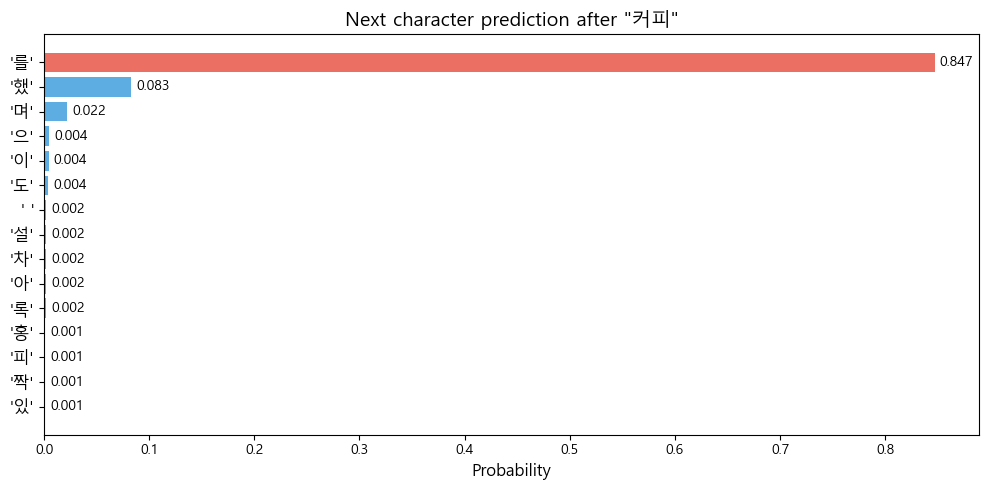

After '커피', the model predicts:
  '를' with probability 0.847
  '했' with probability 0.083
  '며' with probability 0.022
  '으' with probability 0.004
  '이' with probability 0.004


In [60]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False 

# ============================================================
# Bonus: Visualize next-token prediction probabilities
# ============================================================

prompt = "커피"
prompt_ids = torch.tensor([encode(prompt)], dtype=torch.long, device=device)

model.eval()
with torch.no_grad():
    logits = model(prompt_ids)
    probs = F.softmax(logits[0, -1, :], dim=-1).cpu()

# Top 15 predictions
top_k = 15
top_probs, top_ids = probs.topk(top_k)

fig, ax = plt.subplots(figsize=(10, 5))

chars_display = [repr(id2char[i.item()]) for i in top_ids]
colors = ['#e74c3c' if id2char[top_ids[0].item()] == id2char[i.item()] else '#3498db' 
          for i in top_ids]

bars = ax.barh(range(top_k-1, -1, -1), top_probs.tolist(), color=colors, alpha=0.8)
ax.set_yticks(range(top_k-1, -1, -1))
ax.set_yticklabels(chars_display, fontsize=12)
ax.set_xlabel('Probability', fontsize=12)
ax.set_title(f'Next character prediction after "{prompt}"', fontsize=14)

for i, (bar, prob) in enumerate(zip(bars, top_probs)):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{prob:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f"After '커피', the model predicts:")
for i in range(min(5, top_k)):
    c = id2char[top_ids[i].item()]
    print(f"  '{c}' with probability {top_probs[i]:.3f}")